In [1]:
# Standard library imports
import os
from math import ceil, sqrt
from typing import Dict, Tuple, List, Optional, Union

# Third-party library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import FactorAnalysis
from pathlib import Path
import pickle
import itertools
from lightning_pose.data.cameras import CameraGroup
import logging
logger = logging.getLogger(__name__)

# Local library imports
from lp3d_analysis.plot import plot_colors, organize_data_structure, generate_paths_with_models_and_ensembles
from lp3d_analysis.maha_organize import process_mahalanobis
from lp3d_analysis.post_process import process_predictions 
from eks.stats import compute_mahalanobis


INFO:2026-03-08 22:11:39,853:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-03-08 22:11:39,855:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [2]:
# dataset_name = 'fly-anipose'
# views = ['Cam-A', 'Cam-B', 'Cam-C', 'Cam-D', 'Cam-E', 'Cam-F']

# dataset_name = 'mirror-mouse-separate'
# views =['bot','top']

# dataset_name = 'chickadee-crop'
# views = ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop']

# dataset_name = 'ibl-mouse'
# views = ['rightCamera','leftCamera']

dataset_name = 'two-mouse'
views = ['Camera0','Camera1', 'Camera2', 'Camera3', 'Camera4']

seed_dirs = ['0','1','2'] # only second seed 
ensemble_seed = '0-2'
ensemble_methods = []
video_dir = 'videos_new'
n_hand_labels = '200'
model_type = 'mvt_3d_loss'

if dataset_name == 'mirror-mouse-separate':
    results_dirs = [
        'test_200_SV_vits_dino', 
        'test_200_MVT_patch_masking',
    ]

    results_configs = {
        
        'test_200_SV_vits_dino': {
            'model_type': 'supervised',  # or whatever the correct model_type is
            'n_hand_labels': '200'
        },

        'test_200_MVT_patch_masking': {
            'model_type': 'multiview_transformer', 
            'n_hand_labels': '200'
        },
        
      
    }

elif dataset_name == 'ibl-mouse':
    results_dirs = [
        'test_200_SV_vits_dino_new_labels', 
        'test_200_multiview_resnet50_new_labels',
    ]
    results_configs = {
        
        'test_200_multiview_resnet50_new_labels': {
            'model_type': 'supervised',  # or whatever the correct model_type is
            'n_hand_labels': '200'
        },

        'test_200_MVT_3d_aug_patch_masking_new_labels': {
            'model_type': 'multiview_transformer', 
            'n_hand_labels': '200'
        },
       
    }

elif dataset_name == 'two-mouse':
    results_dirs = [
        'test_100_SV_vits_dino', 
        'test_100_MVT_3d_loss_patch_masking',
    ]
    results_configs = {
        
       'test_100_SV_vits_dino': {
            'model_type': 'supervised',  # or whatever the correct model_type is
            'n_hand_labels': '100'
        },

        'test_100_MVT_3d_loss_patch_masking': {
            'model_type': 'mvt_3d_loss', 
            'n_hand_labels': '100'
        },
       
    }

else:
    results_dirs = [
        'test_200_SV_vits_dino', 
        'test_200_MVT_3d_loss_patch_masking_384',
    ]
    results_configs = {
        
        'test_200_SV_vits_dino': {
            'model_type': 'supervised',  # or whatever the correct model_type is
            'n_hand_labels': '200'
        },

        'test_200_MVT_3d_loss_patch_masking': {
            'model_type': 'mvt_3d_loss', 
            'n_hand_labels': '200'
        },
       
    }

camera_params_dir = f'/teamspace/studios/data/{dataset_name}/calibrations'

if dataset_name == 'mirror-mouse-separate':
    session_name  = '180607_004' # for mirror mouse

elif dataset_name == 'chickadee-crop':
    session_name  = 'PRL43_200617_131904' # for chickadee

elif dataset_name == 'fly-anipose':
    session_name  = '05272019_fly4_0_R1C24_rot-ccw-0.06_sec' # for fly anipose

elif dataset_name == 'ibl-mouse':
    session_name = '_iblrig_.downsampled.9b528ad0-4599-4a55-9148-96cc1d93fb24'

elif dataset_name == 'two-mouse':
    session_name = 'CSDS-Day1-A_1-Defeat'

original_session_name = session_name 



if dataset_name == 'mirror-mouse-separate':
    pca_model_path = "/teamspace/studios/this_studio/ZZ_pca_objects/pca_object_inD_mirror-mouse-separate.pkl"

    # # Custom function to force pickle to find NaNPCA2 in pca_global
    class CustomUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if name == "NaNPCA":
                from lightning_pose.utils.pca import  NaNPCA
                return NaNPCA
            
            return super().find_class(module, name)

    # Load PCA object before defining functions
    try:
        with open(pca_model_path, "rb") as f:
            pca_object = CustomUnpickler(f).load()
        print(f"PCA model loaded successfully from {pca_model_path}.")
    except AttributeError as e:
        print(f"Error loading PCA model: {e}. Ensure NaNPCA2 is correctly imported from pca_global.py.")
    except FileNotFoundError as e:
        print(f"Skipping loading pca_object from {pca_model_path}:")
        print(e)
    
    pca_model = pca_object




In [3]:
from lp3d_analysis.utils import generate_comprehensive_paths_multi_results

In_Dist_paths, Out_Dist_paths, all_file_paths = generate_comprehensive_paths_multi_results(
    dataset_name, views, results_configs, video_dir, 
    seed_dirs, ensemble_seed=ensemble_seed, ensemble_methods=ensemble_methods,
    include_seeds=True, include_ensembles=False
)


=== Processing results directory: test_100_SV_vits_dino ===
    Model type: supervised, Labels: 100
  Checking seed dir: /teamspace/studios/this_studio/outputs/two-mouse/test_100_SV_vits_dino/supervised_100_0/videos_new
    EXISTS: Added test_100_SV_vits_dino_seed_0
  Checking seed dir: /teamspace/studios/this_studio/outputs/two-mouse/test_100_SV_vits_dino/supervised_100_1/videos_new
    EXISTS: Added test_100_SV_vits_dino_seed_1
  Checking seed dir: /teamspace/studios/this_studio/outputs/two-mouse/test_100_SV_vits_dino/supervised_100_2/videos_new
    EXISTS: Added test_100_SV_vits_dino_seed_2
  Total directories found for test_100_SV_vits_dino: 3
  Processing test_100_SV_vits_dino_seed_0: /teamspace/studios/this_studio/outputs/two-mouse/test_100_SV_vits_dino/supervised_100_0/videos_new
    Found 40 CSV files
      Added CSDS-Day5-A_12-Defeat -> Camera0 -> test_100_SV_vits_dino_seed_0
      Added CSDS-Day1-A_1-Defeat -> Camera2 -> test_100_SV_vits_dino_seed_0
      Added CSDS-Day9-A_7


=== Processing results directory: test_200_multiview_resnet50_new_labels ===
    Model type: supervised, Labels: 200
  Checking seed dir: /teamspace/studios/this_studio/outputs/ibl-mouse/test_200_multiview_resnet50_new_labels/supervised_200_0/videos_new
    EXISTS: Added test_200_multiview_resnet50_new_labels_seed_0
  Checking seed dir: /teamspace/studios/this_studio/outputs/ibl-mouse/test_200_multiview_resnet50_new_labels/supervised_200_1/videos_new
    EXISTS: Added test_200_multiview_resnet50_new_labels_seed_1
  Checking seed dir: /teamspace/studios/this_studio/outputs/ibl-mouse/test_200_multiview_resnet50_new_labels/supervised_200_2/videos_new
    EXISTS: Added test_200_multiview_resnet50_new_labels_seed_2
  Total directories found for test_200_multiview_resnet50_new_labels: 3
  Processing test_200_multiview_resnet50_new_labels_seed_0: /teamspace/studios/this_studio/outputs/ibl-mouse/test_200_multiview_resnet50_new_labels/supervised_200_0/videos_new
    Found 16 CSV files
      Ad

In [4]:
all_file_paths

{'CSDS-Day5-A_12-Defeat': {'Camera0': {'test_100_SV_vits_dino_seed_0': '/teamspace/studios/this_studio/outputs/two-mouse/test_100_SV_vits_dino/supervised_100_0/videos_new/CSDS-Day5-A_12-Defeat_Camera0.csv',
   'test_100_SV_vits_dino_seed_1': '/teamspace/studios/this_studio/outputs/two-mouse/test_100_SV_vits_dino/supervised_100_1/videos_new/CSDS-Day5-A_12-Defeat_Camera0.csv',
   'test_100_SV_vits_dino_seed_2': '/teamspace/studios/this_studio/outputs/two-mouse/test_100_SV_vits_dino/supervised_100_2/videos_new/CSDS-Day5-A_12-Defeat_Camera0.csv',
   'test_100_MVT_3d_loss_patch_masking_seed_0': '/teamspace/studios/this_studio/outputs/two-mouse/test_100_MVT_3d_loss_patch_masking/mvt_3d_loss_100_0/videos_new/CSDS-Day5-A_12-Defeat_Camera0.csv',
   'test_100_MVT_3d_loss_patch_masking_seed_1': '/teamspace/studios/this_studio/outputs/two-mouse/test_100_MVT_3d_loss_patch_masking/mvt_3d_loss_100_1/videos_new/CSDS-Day5-A_12-Defeat_Camera0.csv',
   'test_100_MVT_3d_loss_patch_masking_seed_2': '/teams

In [5]:
all_file_paths.keys()
# I want the first key
first_key = list(all_file_paths.keys())[0]
print(first_key)
# if the session name doesn't equal the first key, then we need to find the session name that is in the first key
if session_name == first_key:
    print("Session name is the first key")
    particular_session_files = all_file_paths[session_name]
else:
    print("Session name is not the first key")
    session_name = first_key
    particular_session_files = all_file_paths[session_name]


CSDS-Day5-A_12-Defeat
Session name is not the first key


In [6]:
def _load_camera_parameters_for_organize(camera_params_dir, dataset_name, session_name):
    """Load camera calibration parameters for data organization."""
    import os
    from pathlib import Path
    
    if not os.path.exists(camera_params_dir):
        print(f"Camera parameters directory not found: {camera_params_dir}")
        return None
    
    # Remove .short from session name for calibration files if present
    base_session_name = session_name.replace('.short', '')
    camera_params_file = Path(camera_params_dir) / f"{base_session_name}.toml"
    
    if not camera_params_file.exists():
        print(f"Camera parameters file not found: {camera_params_file}")
        return None
    
    try:
        camera_group = CameraGroup.load(str(camera_params_file))
        print(f"Loaded camera parameters for session: {base_session_name}")
        return camera_group
    except Exception as e:
        print(f"Failed to load camera parameters for session {base_session_name}: {e}")
        return None


In [7]:
def organize_data_structure_multimodel(file_paths, views, results_configs, seed_dirs, ensemble_methods=None, 
                                      include_pixel_error=False, n_frames=None, camera_params_dir=None, 
                                      dataset_name=None, session_name=None, include_3d_reconstruction=False,
                                      pca_model=None):  # Add PCA model parameter
    """
    Organize data structure for multiple model types with seeds, including uncropped data and bbox support.
    
    Args:
        file_paths: Dictionary with structure {view: {model_seed_key: filepath}}
        views: List of camera views
        results_configs: Dictionary mapping result_dir to config info
        seed_dirs: List of seed directories
        ensemble_methods: List of ensemble methods (optional)
        include_pixel_error: Whether to include pixel error data
        n_frames: Number of frames to process (int or tuple)
        camera_params_dir: Directory containing camera calibration files
        dataset_name: Name of the dataset
        session_name: Name of the session for camera calibration
        include_3d_reconstruction: Whether to perform 3D reconstruction and reprojection
        pca_model: Pre-trained PCA model to use for 3D reconstruction (optional)
    
    Returns:
        organized_data: Nested dictionary organized by model type, then view
    """
    
    # Determine frame indices
    if isinstance(n_frames, tuple):
        start_frame, end_frame = n_frames
    else:
        start_frame, end_frame = 0, n_frames
    
    organized_data = {}
    
    # Load camera parameters if 3D reconstruction is requested
    camera_group = None
    reconstruction_method = None
    if include_3d_reconstruction and camera_params_dir and dataset_name and session_name:
        camera_group = _load_camera_parameters_for_organize(camera_params_dir, dataset_name, session_name)
        if camera_group:
            print("Camera parameters loaded successfully for 3D reconstruction during data organization")
            reconstruction_method = 'triangulation'
        else:
            print("Camera parameters not found, will use PCA-based 3D reconstruction")
            reconstruction_method = 'pca'
    elif include_3d_reconstruction:
        print("No camera parameters provided, will use PCA-based 3D reconstruction")
        reconstruction_method = 'pca'
    
    # Group file paths by model type
    model_file_paths = {}
    for view in views:
        model_file_paths[view] = {}
        for model_seed_key, filepath in file_paths[view].items():
            # Extract model type from the key
            # Assuming format like 'test_200_MVT_3d_loss_patch_masking_seed_0'
            parts = model_seed_key.split('_seed_')
            if len(parts) == 2:
                model_key = parts[0]  # e.g., 'test_200_MVT_3d_loss_patch_masking'
                seed = parts[1]       # e.g., '0'
                
                if model_key not in model_file_paths[view]:
                    model_file_paths[view][model_key] = {}
                model_file_paths[view][model_key][seed] = filepath
    
    # Process each model type
    for model_key, config in results_configs.items():
        model_type = config['model_type']
        n_hand_labels = config['n_hand_labels']
        
        organized_data[model_key] = {}
        
        for view_idx, view in enumerate(views):
            # Skip if this model doesn't have data for this view
            if model_key not in model_file_paths[view]:
                continue
                
            # Get keypoints from first available file for this model and view
            first_seed = next(iter(model_file_paths[view][model_key].keys()))
            first_csv = model_file_paths[view][model_key][first_seed]
            
            try:
                first_df = pd.read_csv(first_csv, header=[0, 1, 2], index_col=0)
                keypoints = list(dict.fromkeys(first_df.columns.get_level_values(1)))
                print(f"Keypoints for {model_key} - {view} view: {keypoints}")
                
                # Remove keypoints that start with 'Unnamed'
                keypoints = [keypoint for keypoint in keypoints if not keypoint.startswith('Unnamed')]
                print(f"Filtered keypoints for {model_key} - {view} view: {keypoints}")
                
            except Exception as e:
                print(f"Error reading {first_csv}: {e}")
                continue
            
            # Initialize data structure with all necessary fields
            organized_data[model_key][view] = {
                'x': {},
                'y': {},
                'x_uncropped': {},  # Store uncropped coordinates
                'y_uncropped': {},  # Store uncropped coordinates
                'bbox_data': {},    # Store bbox information
                'likelihood': {},
                'x_ens_var': {},
                'y_ens_var': {},
                'x_posterior_var': {},
                'y_posterior_var': {},
                'pixel_error': {},
                'mahalanobis': {},
                'keypoints_3d': {},  # Store 3D keypoints
                'x_reconstructed': {},  # Store reprojected x coordinates
                'y_reconstructed': {},  # Store reprojected y coordinates
                'reprojection_error': {},  # Store reprojection errors
                'x_reprojection_error': {},  # Store reprojection errors
                'y_reprojection_error': {},  # Store reprojection errors
                'avg_reprojection_error': {},  # existing (mean(|dx|, |dy|))
                'keypoints': keypoints,
                'model_type': model_type,
                'n_hand_labels': n_hand_labels,
                'has_uncropped_data': False,  # Flag to track if uncropped data exists
                'has_bbox_data': False,  # Flag to track if bbox data exists
                'reconstruction_method': reconstruction_method  # Store reconstruction method used
            }
            
            # Process each seed for this model
            for seed in seed_dirs:
                if seed not in model_file_paths[view][model_key]:
                    print(f"Seed {seed} not found for model {model_key} in view {view}")
                    continue
                    
                filepath = model_file_paths[view][model_key][seed]
                
                try:
                    # Load main CSV file
                    df = pd.read_csv(filepath, header=[0, 1, 2], index_col=0)
                    df = df.iloc[start_frame:end_frame]  # Select specific range of frames
                    
                    key = f'seed_{seed}'
                    organized_data[model_key][view]['x'][key] = df.loc[:, df.columns.get_level_values(2) == 'x'].values
                    organized_data[model_key][view]['y'][key] = df.loc[:, df.columns.get_level_values(2) == 'y'].values
                    
                    # Check for uncropped data by looking for files ending with _uncropped.csv in the same directory
                    file_dir = os.path.dirname(filepath)
                    file_basename = os.path.basename(filepath).replace('.csv', '')
                    
                    # Look for uncropped file with pattern: {basename}_uncropped.csv
                    uncropped_filepath = os.path.join(file_dir, f"{file_basename}_uncropped.csv")
                    
                    if os.path.exists(uncropped_filepath):
                        try:
                            df_uncropped = pd.read_csv(uncropped_filepath, header=[0, 1, 2], index_col=0)
                            df_uncropped = df_uncropped.iloc[start_frame:end_frame]
                            
                            organized_data[model_key][view]['x_uncropped'][key] = df_uncropped.loc[:, df_uncropped.columns.get_level_values(2) == 'x'].values
                            organized_data[model_key][view]['y_uncropped'][key] = df_uncropped.loc[:, df_uncropped.columns.get_level_values(2) == 'y'].values
                            organized_data[model_key][view]['has_uncropped_data'] = True
                            print(f"✓ Loaded uncropped data for {key} in {model_key} - {view}: {uncropped_filepath}")
                        except Exception as e:
                            print(f"✗ Error loading uncropped data for {key}: {e}")
                    else:
                        print(f"- No uncropped file found: {uncropped_filepath}")
                    
                    # Check for bbox data by looking for files ending with _bbox.csv in the same directory
                    bbox_filepath = f'/teamspace/studios/data/{dataset_name}/{video_dir}/{original_session_name}_{view}.short_bbox.csv'
                    
                    if os.path.exists(bbox_filepath):
                        try:
                            df_bbox = pd.read_csv(bbox_filepath, index_col=0)
                            df_bbox = df_bbox.iloc[start_frame:end_frame]
                            
                            # Store bbox data as dict with x, y, w, h for each frame
                            if all(col in df_bbox.columns for col in ['x', 'y', 'w', 'h']):
                                bbox_data = {
                                    'x': df_bbox['x'].values,
                                    'y': df_bbox['y'].values,
                                    'w': df_bbox['w'].values,
                                    'h': df_bbox['h'].values
                                }
                                organized_data[model_key][view]['bbox_data'][key] = bbox_data
                                organized_data[model_key][view]['has_bbox_data'] = True
                                print(f"✓ Loaded bbox data for {key} in {model_key} - {view}: {bbox_filepath}")
                            else:
                                print(f"✗ Bbox file missing required columns (x, y, w, h): {bbox_filepath}")
                        except Exception as e:
                            print(f"✗ Error loading bbox data for {key}: {e}")
                    else:
                        print(f"- No bbox file found: {bbox_filepath}")
                    
                    # Add likelihood if available
                    if any(col == 'likelihood' for col in df.columns.get_level_values(2)):
                        organized_data[model_key][view]['likelihood'][key] = df.loc[:, df.columns.get_level_values(2) == 'likelihood'].values
                    
                    # Add pixel error if requested
                    if include_pixel_error:
                        pixel_error_path = filepath.replace('.csv', '_pixel_error.csv')
                        try:
                            df_error = pd.read_csv(pixel_error_path, header=[0], index_col=0)
                            df_error = df_error.iloc[start_frame:end_frame]
                            if 'set' in df_error.columns:
                                df_error = df_error.drop(columns=['set'])
                            organized_data[model_key][view]['pixel_error'][key] = df_error.values
                        except (FileNotFoundError, pd.errors.EmptyDataError):
                            print(f"Pixel error file not found or empty for {key} in {model_key} - {view} view")
                
                except Exception as e:
                    print(f"Error processing {filepath}: {e}")
                    continue
        
        # Process ensemble methods if provided
        if ensemble_methods:
            for method in ensemble_methods:
                # Look for ensemble files for this model
                ensemble_key = f"{model_key}_{method}"
                
                for view in views:
                    if ensemble_key in file_paths[view]:
                        filepath = file_paths[view][ensemble_key]
                        
                        try:
                            df = pd.read_csv(filepath, header=[0, 1, 2], index_col=0)
                            df = df.iloc[start_frame:end_frame]
                            
                            if view not in organized_data[model_key]:
                                continue
                                
                            organized_data[model_key][view]['x'][method] = df.loc[:, df.columns.get_level_values(2) == 'x'].values
                            organized_data[model_key][view]['y'][method] = df.loc[:, df.columns.get_level_values(2) == 'y'].values
                            organized_data[model_key][view]['likelihood'][method] = df.loc[:, df.columns.get_level_values(2) == 'likelihood'].values
                            
                            # Add variances if available
                            level_2_cols = df.columns.get_level_values(2)
                            
                            # Ensemble variance
                            if any(col == 'x_ens_var' for col in level_2_cols):
                                organized_data[model_key][view]['x_ens_var'][method] = df.loc[:, df.columns.get_level_values(2) == 'x_ens_var'].values
                                organized_data[model_key][view]['y_ens_var'][method] = df.loc[:, df.columns.get_level_values(2) == 'y_ens_var'].values
                            
                            # Posterior variance
                            if any(col == 'x_posterior_var' for col in level_2_cols):
                                organized_data[model_key][view]['x_posterior_var'][method] = df.loc[:, df.columns.get_level_values(2) == 'x_posterior_var'].values
                                organized_data[model_key][view]['y_posterior_var'][method] = df.loc[:, df.columns.get_level_values(2) == 'y_posterior_var'].values
                            
                            # Check for uncropped and bbox data for ensemble methods too
                            file_dir = os.path.dirname(filepath)
                            file_basename = os.path.basename(filepath).replace('.csv', '')
                            
                            # Uncropped ensemble data
                            uncropped_filepath = os.path.join(file_dir, f"{file_basename}_uncropped.csv")
                            if os.path.exists(uncropped_filepath):
                                try:
                                    df_uncropped = pd.read_csv(uncropped_filepath, header=[0, 1, 2], index_col=0)
                                    df_uncropped = df_uncropped.iloc[start_frame:end_frame]
                                    organized_data[model_key][view]['x_uncropped'][method] = df_uncropped.loc[:, df_uncropped.columns.get_level_values(2) == 'x'].values
                                    organized_data[model_key][view]['y_uncropped'][method] = df_uncropped.loc[:, df_uncropped.columns.get_level_values(2) == 'y'].values
                                    organized_data[model_key][view]['has_uncropped_data'] = True
                                    print(f"✓ Loaded uncropped ensemble data for {method}")
                                except Exception as e:
                                    print(f"✗ Error loading uncropped ensemble data: {e}")
                            
                            # Bbox ensemble data
                            bbox_filepath = f'/teamspace/studios/data/{dataset_name}/{video_dir}/{original_session_name}_{view}.short_bbox.csv'
                            print(f"Bbox file path: {bbox_filepath}")

                            if os.path.exists(bbox_filepath):
                                try:
                                    df_bbox = pd.read_csv(bbox_filepath, index_col=0)
                                    df_bbox = df_bbox.iloc[start_frame:end_frame]
                                    if all(col in df_bbox.columns for col in ['x', 'y', 'w', 'h']):
                                        bbox_data = {
                                            'x': df_bbox['x'].values,
                                            'y': df_bbox['y'].values,
                                            'w': df_bbox['w'].values,
                                            'h': df_bbox['h'].values
                                        }
                                        organized_data[model_key][view]['bbox_data'][method] = bbox_data
                                        organized_data[model_key][view]['has_bbox_data'] = True
                                        print(f"✓ Loaded bbox ensemble data for {method}")
                                except Exception as e:
                                    print(f"✗ Error loading bbox ensemble data: {e}")
                            
                            # Add pixel error if requested
                            if include_pixel_error:
                                pixel_error_path = filepath.replace('.csv', '_pixel_error.csv')
                                try:
                                    df_error = pd.read_csv(pixel_error_path, header=[0], index_col=0)
                                    df_error = df_error.iloc[start_frame:end_frame]
                                    if 'set' in df_error.columns:
                                        df_error = df_error.drop(columns=['set'])
                                    organized_data[model_key][view]['pixel_error'][method] = df_error.values
                                except (FileNotFoundError, pd.errors.EmptyDataError):
                                    print(f"Pixel error file not found or empty for {method} in {model_key} - {view} view")
                        
                        except Exception as e:
                            print(f"Error processing ensemble file {filepath}: {e}")
                            continue
    
    # Perform 3D reconstruction and calculate reprojection errors if requested
    if include_3d_reconstruction:
        if reconstruction_method == 'triangulation' and camera_group:
            organized_data = _add_3d_reconstruction_to_data(organized_data, views, camera_group, seed_dirs, ensemble_methods)
        elif reconstruction_method == 'pca':
            if pca_model is not None:
                print(f"Using provided PCA model for 3D reconstruction")
                organized_data = _add_pca_3d_reconstruction_to_data_with_model(organized_data, views, seed_dirs, ensemble_methods, pca_model)
            else:
                print("No PCA model provided, fitting new PCA for each frame")
                organized_data = _add_pca_3d_reconstruction_to_data(organized_data, views, seed_dirs, ensemble_methods)
    
    return organized_data


In [8]:

def _add_pca_3d_reconstruction_to_data_with_model(organized_data, views, seed_dirs, ensemble_methods, pca_model):
    """Add PCA-based 3D reconstruction using a pre-trained PCA model."""
    
    print("Adding PCA-based 3D reconstruction using provided PCA model...")
    
    # Get all methods to process
    all_methods = [f'seed_{seed}' for seed in seed_dirs]
    if ensemble_methods:
        all_methods.extend(ensemble_methods)
    
    for model_key in organized_data.keys():
        print(f"Processing PCA 3D reconstruction for model: {model_key}")
        
        # Check data availability
        has_uncropped_data = any(organized_data[model_key][view].get('has_uncropped_data', False) 
                               for view in views if view in organized_data[model_key])
        has_bbox_data = any(organized_data[model_key][view].get('has_bbox_data', False) 
                          for view in views if view in organized_data[model_key])
        
        for method in all_methods:
            # Check if method exists
            method_exists = all(
                method in organized_data[model_key][view]['x'] 
                for view in views 
                if view in organized_data[model_key]
            )
            
            if not method_exists:
                continue
            
            # Get dimensions
            first_view = next(view for view in views if view in organized_data[model_key])
            n_frames, n_keypoints = organized_data[model_key][first_view]['x'][method].shape
            
            # STEP 1: PROJECT (2D → 3D) using provided PCA model
            keypoints_3d_array = _project_2d_to_3d_with_provided_pca(
                organized_data, model_key, method, views, n_frames, n_keypoints, 
                has_uncropped_data, has_bbox_data, pca_model
            )
            
            # Store 3D keypoints
            for view in views:
                if view in organized_data[model_key]:
                    organized_data[model_key][view]['keypoints_3d'][method] = keypoints_3d_array
            
            # STEP 2: REPROJECT (3D → 2D) using PCA inverse transform
            for view in views:
                if view in organized_data[model_key]:
                    # Get original coordinates for comparison
                    if (has_uncropped_data and method in organized_data[model_key][view].get('x_uncropped', {})):
                        x_original = organized_data[model_key][view]['x_uncropped'][method]
                        y_original = organized_data[model_key][view]['y_uncropped'][method]
                    else:
                        x_original = organized_data[model_key][view]['x'][method]
                        y_original = organized_data[model_key][view]['y'][method]
                    
                    # REPROJECT: Use PCA inverse transform
                    x_reconstructed, y_reconstructed = _reproject_3d_to_2d_with_provided_pca(
                        keypoints_3d_array, pca_model, view, views, n_frames, n_keypoints
                    )
                    
                    # Calculate reprojection errors
                    x_error = np.abs(x_original - x_reconstructed)
                    print(f"    X reprojection error: {x_error}")
                    y_error = np.abs(y_original - y_reconstructed)
                    print(f"    Y reprojection error: {y_error}")
                    euclidean_error = np.sqrt(x_error**2 + y_error**2)
                    avg_error = (x_error + y_error) / 2
                    
                    # Store results
                    organized_data[model_key][view]['x_reconstructed'][method] = x_reconstructed
                    organized_data[model_key][view]['y_reconstructed'][method] = y_reconstructed
                    organized_data[model_key][view]['reprojection_error'][method] = euclidean_error
                    organized_data[model_key][view]['avg_reprojection_error'][method] = avg_error
                    organized_data[model_key][view]['x_reprojection_error'][method] = x_error
                    organized_data[model_key][view]['y_reprojection_error'][method] = y_error

                    
                    print(f"    PROJECTED 2D→3D and REPROJECTED 3D→2D for {view}")
                    print(f"    Mean reprojection error: {np.nanmean(euclidean_error):.3f}")
    
    print("PCA project-reproject cycle with provided model completed")
    return organized_data


def _project_2d_to_3d_with_provided_pca(organized_data, model_key, method, views, n_frames, n_keypoints, has_uncropped_data, has_bbox_data, pca_model):
    """Project 2D points to 3D using a provided PCA model."""
    import numpy as np
    
    keypoints_3d_all_frames = []
    
    for frame_idx in range(n_frames):
        # Collect 2D points from all views
        points_2d_all_views = []
        
        for view in views:
            if view in organized_data[model_key] and method in organized_data[model_key][view]['x']:
                # Get 2D coordinates
                if (has_uncropped_data and method in organized_data[model_key][view].get('x_uncropped', {})):
                    x_coords = organized_data[model_key][view]['x_uncropped'][method][frame_idx, :]
                    y_coords = organized_data[model_key][view]['y_uncropped'][method][frame_idx, :]
                else:
                    x_coords = organized_data[model_key][view]['x'][method][frame_idx, :]
                    y_coords = organized_data[model_key][view]['y'][method][frame_idx, :]
                
                # Check validity
                valid_mask = ~(np.isnan(x_coords) | np.isnan(y_coords) | np.isinf(x_coords) | np.isinf(y_coords))
                if np.sum(valid_mask) > n_keypoints * 0.5:
                    points_2d_all_views.append(np.column_stack([x_coords, y_coords]))
        
        # PROJECT: 2D (multiple views) → 3D using provided PCA model
        if len(points_2d_all_views) >= 2:
            try:
                keypoints_2d_stacked = np.stack(points_2d_all_views, axis=1)  # (n_keypoints, n_views, 2)
                keypoints_2d_flat = keypoints_2d_stacked.reshape(n_keypoints, -1)  # (n_keypoints, n_views * 2)
                
                # Use provided PCA model to transform
                keypoints_3d = pca_model.transform(keypoints_2d_flat)
                
                # Pad to 3D if needed
                if keypoints_3d.shape[1] < 3:
                    padding = np.zeros((keypoints_3d.shape[0], 3 - keypoints_3d.shape[1]))
                    keypoints_3d = np.hstack([keypoints_3d, padding])
                
                keypoints_3d_all_frames.append(keypoints_3d)
                
            except Exception as e:
                print(f"    PCA transformation failed for frame {frame_idx}: {e}")
                keypoints_3d_all_frames.append(np.full((n_keypoints, 3), np.nan))
        else:
            keypoints_3d_all_frames.append(np.full((n_keypoints, 3), np.nan))
    
    return np.stack(keypoints_3d_all_frames)


def _reproject_3d_to_2d_with_provided_pca(keypoints_3d_array, pca_model, target_view, all_views, n_frames, n_keypoints):
    """Reproject 3D points back to 2D using provided PCA model inverse transform."""
    import numpy as np
    
    x_reconstructed = np.full((n_frames, n_keypoints), np.nan)
    y_reconstructed = np.full((n_frames, n_keypoints), np.nan)
    
    for frame_idx in range(n_frames):
        try:
            # Get 3D points for this frame
            keypoints_3d_frame = keypoints_3d_array[frame_idx]  # Shape: (n_keypoints, 3)
            
            # Use PCA inverse transform to get back to original 2D space
            reconstructed_2d_flat = pca_model.inverse_transform(keypoints_3d_frame[:, :pca_model.n_components_])
            
            # Reshape back to (n_keypoints, n_views, 2)
            n_views = len(all_views)
            reconstructed_2d_stacked = reconstructed_2d_flat.reshape(n_keypoints, n_views, 2)
            
            # Get the coordinates for the target view
            view_idx = all_views.index(target_view)
            if view_idx < reconstructed_2d_stacked.shape[1]:
                x_reconstructed[frame_idx] = reconstructed_2d_stacked[:, view_idx, 0]
                y_reconstructed[frame_idx] = reconstructed_2d_stacked[:, view_idx, 1]
            
        except Exception as e:
            print(f"    PCA inverse transform failed for frame {frame_idx}: {e}")
            x_reconstructed[frame_idx] = np.full(n_keypoints, np.nan)
            y_reconstructed[frame_idx] = np.full(n_keypoints, np.nan)
    
    return x_reconstructed, y_reconstructed


def _add_pca_3d_reconstruction_to_data(organized_data, views, seed_dirs, ensemble_methods):
    """Add PCA-based 3D reconstruction data to organized data (fitting new PCA per frame).
       Reprojection errors are not meaningful per-frame; fill with NaN, including per-axis."""
    from sklearn.decomposition import PCA
    import numpy as np

    print("Adding PCA-based 3D reconstruction (fitting new PCA for each frame)...")

    all_methods = [f'seed_{seed}' for seed in seed_dirs]
    if ensemble_methods:
        all_methods.extend(ensemble_methods)

    for model_key in organized_data.keys():
        print(f"Processing PCA 3D reconstruction for model: {model_key}")

        has_uncropped_data = any(
            organized_data[model_key][view].get('has_uncropped_data', False)
            for view in views if view in organized_data[model_key]
        )
        has_bbox_data = any(
            organized_data[model_key][view].get('has_bbox_data', False)
            for view in views if view in organized_data[model_key]
        )

        for method in all_methods:
            method_exists = all(
                view in organized_data[model_key] and method in organized_data[model_key][view]['x']
                for view in views if view in organized_data[model_key]
            )
            if not method_exists:
                continue

            first_view = next(view for view in views if view in organized_data[model_key])
            n_frames, n_keypoints = organized_data[model_key][first_view]['x'][method].shape

            # 1) PROJECT 2D -> 3D (per-frame PCA)
            keypoints_3d_array = _project_2d_to_3d_with_pca(
                organized_data, model_key, method, views, n_frames, n_keypoints,
                has_uncropped_data, has_bbox_data
            )

            # store 3D and NaN reprojection info
            for view in views:
                if view not in organized_data[model_key]:
                    continue
                organized_data[model_key][view]['keypoints_3d'][method] = keypoints_3d_array

                # Not meaningful for per-frame PCA → fill with NaN
                organized_data[model_key][view]['x_reconstructed'][method] = np.full((n_frames, n_keypoints), np.nan)
                organized_data[model_key][view]['y_reconstructed'][method] = np.full((n_frames, n_keypoints), np.nan)
                organized_data[model_key][view]['reprojection_error'][method] = np.full((n_frames, n_keypoints), np.nan)
                organized_data[model_key][view]['avg_reprojection_error'][method] = np.full((n_frames, n_keypoints), np.nan)
                organized_data[model_key][view]['x_reprojection_error'][method] = np.full((n_frames, n_keypoints), np.nan)  # NEW
                organized_data[model_key][view]['y_reprojection_error'][method] = np.full((n_frames, n_keypoints), np.nan)  # NEW

                print(f"    PCA 3D reconstruction completed for {view} (per-frame PCA: reprojection errors set to NaN)")

    print("PCA-based 3D reconstruction completed")
    return organized_data


def _project_2d_to_3d_with_pca(organized_data, model_key, method, views, n_frames, n_keypoints, has_uncropped_data, has_bbox_data):
    """Project 2D points to 3D using PCA (fitting new PCA for each frame)."""
    from sklearn.decomposition import PCA
    import numpy as np
    
    keypoints_3d_all_frames = []
    
    for frame_idx in range(n_frames):
        # Collect 2D points from all views
        points_2d_all_views = []
        
        for view in views:
            if view in organized_data[model_key] and method in organized_data[model_key][view]['x']:
                # Get 2D coordinates
                if (has_uncropped_data and method in organized_data[model_key][view].get('x_uncropped', {})):
                    x_coords = organized_data[model_key][view]['x_uncropped'][method][frame_idx, :]
                    y_coords = organized_data[model_key][view]['y_uncropped'][method][frame_idx, :]
                else:
                    x_coords = organized_data[model_key][view]['x'][method][frame_idx, :]
                    y_coords = organized_data[model_key][view]['y'][method][frame_idx, :]
                
                # Check validity
                valid_mask = ~(np.isnan(x_coords) | np.isnan(y_coords) | np.isinf(x_coords) | np.isinf(y_coords))
                if np.sum(valid_mask) > n_keypoints * 0.5:
                    points_2d_all_views.append(np.column_stack([x_coords, y_coords]))
        
        # PROJECT: 2D (multiple views) → 3D using PCA
        if len(points_2d_all_views) >= 2:
            try:
                keypoints_2d_stacked = np.stack(points_2d_all_views, axis=1)  # (n_keypoints, n_views, 2)
                keypoints_2d_flat = keypoints_2d_stacked.reshape(n_keypoints, -1)  # (n_keypoints, n_views * 2)
                
                n_components = min(3, keypoints_2d_flat.shape[1])
                pca = PCA(n_components=n_components)
                keypoints_3d = pca.fit_transform(keypoints_2d_flat)
                
                # Pad to 3D if needed
                if keypoints_3d.shape[1] < 3:
                    padding = np.zeros((keypoints_3d.shape[0], 3 - keypoints_3d.shape[1]))
                    keypoints_3d = np.hstack([keypoints_3d, padding])
                
                keypoints_3d_all_frames.append(keypoints_3d)
                
            except Exception as e:
                print(f"    PCA reconstruction failed for frame {frame_idx}: {e}")
                keypoints_3d_all_frames.append(np.full((n_keypoints, 3), np.nan))
        else:
            keypoints_3d_all_frames.append(np.full((n_keypoints, 3), np.nan))
    
    return np.stack(keypoints_3d_all_frames)


def _add_3d_reconstruction_to_data(organized_data, views, camera_group, seed_dirs, ensemble_methods):
    """Add 3D reconstruction and reprojection error data to organized data."""
    
    print("Adding 3D reconstruction data to organized structure...")
    
    # Get all methods to process (seeds + ensemble methods)
    all_methods = [f'seed_{seed}' for seed in seed_dirs]
    if ensemble_methods:
        all_methods.extend(ensemble_methods)
    
    for model_key in organized_data.keys():
        print(f"Processing 3D reconstruction for model: {model_key}")
        
        # Get keypoints from first view
        first_view = next(iter(organized_data[model_key].keys()))
        keypoints = organized_data[model_key][first_view]['keypoints']
        
        # Check if we have uncropped data for this model
        has_uncropped_data = any(organized_data[model_key][view].get('has_uncropped_data', False) 
                               for view in views if view in organized_data[model_key])
        has_bbox_data = any(organized_data[model_key][view].get('has_bbox_data', False) 
                          for view in views if view in organized_data[model_key])
        
        print(f"  Model has uncropped data: {has_uncropped_data}")
        print(f"  Model has bbox data: {has_bbox_data}")
        
        for method in all_methods:
            print(f"  Processing method: {method}")
            
            # Check if method exists in all views
            method_exists = all(
                method in organized_data[model_key][view]['x'] 
                for view in views 
                if view in organized_data[model_key]
            )
            
            if not method_exists:
                print(f"    Method {method} not found in all views, skipping")
                continue
            
            # Get data dimensions
            first_view_with_method = next(
                view for view in views 
                if view in organized_data[model_key] and method in organized_data[model_key][view]['x']
            )
            n_frames, n_keypoints = organized_data[model_key][first_view_with_method]['x'][method].shape
            
            # Initialize storage for 3D points and reprojection data
            keypoints_3d_all_frames = []
            
            # Process each frame
            for frame_idx in range(n_frames):
                # Collect 2D points from all views for this frame
                points_2d_all_views = []
                valid_views = []
                
                for view in views:
                    if (view in organized_data[model_key] and 
                        method in organized_data[model_key][view]['x']):
                        
                        # PRIORITY: Use uncropped data for triangulation if available
                        if (has_uncropped_data and 
                            method in organized_data[model_key][view].get('x_uncropped', {})):
                            x_coords = organized_data[model_key][view]['x_uncropped'][method][frame_idx, :]
                            y_coords = organized_data[model_key][view]['y_uncropped'][method][frame_idx, :]
                            print(f"    Using uncropped data for triangulation: {view}, frame {frame_idx}")
                        else:
                            # Fall back to cropped data
                            x_coords = organized_data[model_key][view]['x'][method][frame_idx, :]
                            y_coords = organized_data[model_key][view]['y'][method][frame_idx, :]
                            print(f"    Using cropped data for triangulation: {view}, frame {frame_idx}")
                        
                        # Check for valid coordinates
                        valid_mask = ~(np.isnan(x_coords) | np.isnan(y_coords) | 
                                     np.isinf(x_coords) | np.isinf(y_coords))
                        
                        if np.sum(valid_mask) > n_keypoints * 0.5:  # At least 50% valid keypoints
                            points_2d = np.column_stack([x_coords, y_coords])
                            points_2d_all_views.append(points_2d)
                            valid_views.append(view)
                
                # Perform triangulation if we have enough views
                if len(points_2d_all_views) >= 2:
                    try:
                        # Stack points: shape (n_views, n_keypoints, 2)
                        points_2d_stacked = np.stack(points_2d_all_views)
                        
                        # Triangulate to get 3D points
                        keypoints_3d = camera_group.triangulate_fast(points_2d_stacked, undistort=True)
                        keypoints_3d_all_frames.append(keypoints_3d)
                        
                    except Exception as e:
                        print(f"    Triangulation failed for frame {frame_idx}: {e}")
                        keypoints_3d_all_frames.append(np.full((n_keypoints, 3), np.nan))
                else:
                    keypoints_3d_all_frames.append(np.full((n_keypoints, 3), np.nan))
            
            # Convert to numpy array: shape (n_frames, n_keypoints, 3)
            keypoints_3d_array = np.stack(keypoints_3d_all_frames)
            
            # Store 3D keypoints for each view (same data, but stored per view for convenience)
            for view in views:
                if view in organized_data[model_key]:
                    organized_data[model_key][view]['keypoints_3d'][method] = keypoints_3d_array
            
            # Calculate reprojection for each view
            for view in views:
                if (view in organized_data[model_key] and 
                    method in organized_data[model_key][view]['x']):
                    
                    try:
                        # Reproject 3D points back to 2D (in uncropped space)
                        reprojected_all_views = camera_group.project(keypoints_3d_array.reshape(-1, 3))
                        reprojected_all_views = reprojected_all_views.reshape(len(views), n_frames, n_keypoints, 2)
                        
                        # Get reprojection for current view
                        view_idx = views.index(view)
                        reprojected_2d_uncropped = reprojected_all_views[view_idx]
                        
                        # Apply bbox transformation if we have bbox data and need to compare with cropped predictions
                        if (has_bbox_data and has_uncropped_data and 
                            method in organized_data[model_key][view].get('bbox_data', {})):
                            
                            bbox_data = organized_data[model_key][view]['bbox_data'][method]
                            reprojected_2d_cropped = _apply_bbox_crop_to_points(
                                reprojected_2d_uncropped, bbox_data, 
                                crop_size=(320, 320)  # Adjust based on your crop size
                            )
                            
                            # Store both uncropped and cropped reprojections
                            organized_data[model_key][view]['x_reconstructed'][method] = reprojected_2d_cropped[:, :, 0]
                            organized_data[model_key][view]['y_reconstructed'][method] = reprojected_2d_cropped[:, :, 1]
                            
                            # Calculate reprojection errors against cropped predictions
                            x_original = organized_data[model_key][view]['x'][method]
                            y_original = organized_data[model_key][view]['y'][method]
                            
                        else:
                            # No bbox transformation needed
                            organized_data[model_key][view]['x_reconstructed'][method] = reprojected_2d_uncropped[:, :, 0]
                            organized_data[model_key][view]['y_reconstructed'][method] = reprojected_2d_uncropped[:, :, 1]
                            
                            # Calculate reprojection errors
                            x_original = organized_data[model_key][view]['x'][method]
                            y_original = organized_data[model_key][view]['y'][method]
                        
                        x_error = np.abs(x_original - organized_data[model_key][view]['x_reconstructed'][method])
                        y_error = np.abs(y_original - organized_data[model_key][view]['y_reconstructed'][method])
                        organized_data[model_key][view]['x_reprojection_error'][method] = x_error
                        organized_data[model_key][view]['y_reprojection_error'][method] = y_error
                        
                        # Euclidean reprojection error
                        euclidean_error = np.sqrt(x_error**2 + y_error**2)
                        organized_data[model_key][view]['reprojection_error'][method] = euclidean_error
                        
                        # Averaged reprojection error (mean of x and y errors)
                        avg_error = (x_error + y_error) / 2
                        organized_data[model_key][view]['avg_reprojection_error'][method] = avg_error

                        
                        
                        print(f"    Successfully calculated reprojection errors for {view}")
                        
                    except Exception as e:
                        print(f"    Reprojection failed for {view}: {e}")
                        # Fill with NaN arrays
                        organized_data[model_key][view]['x_reconstructed'][method] = np.full((n_frames, n_keypoints), np.nan)
                        organized_data[model_key][view]['y_reconstructed'][method] = np.full((n_frames, n_keypoints), np.nan)
                        organized_data[model_key][view]['reprojection_error'][method] = np.full((n_frames, n_keypoints), np.nan)
                        organized_data[model_key][view]['avg_reprojection_error'][method] = np.full((n_frames, n_keypoints), np.nan)
                        organized_data[model_key][view]['x_reprojection_error'][method] = np.full((n_frames, n_keypoints), np.nan)
                        organized_data[model_key][view]['y_reprojection_error'][method] = np.full((n_frames, n_keypoints), np.nan)
    
    print("3D reconstruction and reprojection error calculation completed")
    return organized_data




def _remap_keypoints_to_original_space(keypoints_2d, bbox_data, img_height=320, img_width=320):
    """Remap keypoints from cropped space back to original space."""
    if bbox_data is None:
        print("No bbox data provided for remapping")
        return keypoints_2d
    
    # Validate required bbox keys
    required_keys = ['x', 'y', 'w', 'h']
    missing_keys = [key for key in required_keys if key not in bbox_data or bbox_data[key] is None]
    
    if missing_keys:
        print(f"Missing bbox keys {missing_keys}. Cannot remap keypoints.")
        return keypoints_2d
    
    # Check for valid bbox dimensions
    if bbox_data['w'] <= 0 or bbox_data['h'] <= 0:
        print(f"Invalid bbox dimensions: w={bbox_data['w']}, h={bbox_data['h']}")
        return keypoints_2d
    
    # Check for NaN/inf values
    bbox_values = [bbox_data[key] for key in required_keys]
    if any(np.isnan(val) or np.isinf(val) for val in bbox_values):
        print("Bbox contains NaN or inf values. Cannot remap keypoints.")
        return keypoints_2d
    
    # This is the inverse of the cropping operation
    # From cropped space (img_width x img_height) back to original space
    remapped_keypoints = keypoints_2d.copy()
    
    # Scale back to original dimensions
    remapped_keypoints[:, 0] = (remapped_keypoints[:, 0] / img_width) * bbox_data['w']
    remapped_keypoints[:, 1] = (remapped_keypoints[:, 1] / img_height) * bbox_data['h']
    
    # Add back the bbox offset
    remapped_keypoints[:, 0] += bbox_data['x']
    remapped_keypoints[:, 1] += bbox_data['y']
    
    return remapped_keypoints


def _apply_bbox_crop_to_points(points_uncropped, bbox_data, crop_size=(320, 320)):
    """
    Apply bbox cropping transformation to uncropped points.
    This follows the same logic as generate_cropped_csv_file with mode="subtract"
    
    Args:
        points_uncropped: Array of shape (n_frames, n_keypoints, 2) in uncropped space
        bbox_data: Dict with 'x', 'y', 'w', 'h' arrays for each frame
        crop_size: Tuple of (width, height) of the cropped image
        
    Returns:
        points_cropped: Array of shape (n_frames, n_keypoints, 2) in cropped space
    """
    
    
    n_frames, n_keypoints, _ = points_uncropped.shape
    points_cropped = np.full_like(points_uncropped, np.nan)
    img_width, img_height = crop_size
    
    for frame_idx in range(n_frames):
        # Get bbox for this frame
        bbox_x = bbox_data['x'][frame_idx]
        bbox_y = bbox_data['y'][frame_idx] 
        bbox_w = bbox_data['w'][frame_idx]
        bbox_h = bbox_data['h'][frame_idx]
        
        # Skip if bbox data is invalid
        if (np.isnan(bbox_x) or np.isnan(bbox_y) or 
            np.isnan(bbox_w) or np.isnan(bbox_h) or 
            bbox_w <= 0 or bbox_h <= 0):
            continue
        
        # Transform points from uncropped space to cropped space
        # Following the same logic as generate_cropped_csv_file with mode="subtract"
        uncropped_points = points_uncropped[frame_idx]  # Shape: (n_keypoints, 2)
        
        # Apply transformation: subtract bbox offset, then scale
        cropped_points = uncropped_points.copy()
        
        # X coordinates: subtract bbox_x, then scale by (img_width / bbox_w)
        cropped_points[:, 0] = cropped_points[:, 0] - bbox_x
        cropped_points[:, 0] = (cropped_points[:, 0] / bbox_w) * img_width
        
        # Y coordinates: subtract bbox_y, then scale by (img_height / bbox_h)  
        cropped_points[:, 1] = cropped_points[:, 1] - bbox_y
        cropped_points[:, 1] = (cropped_points[:, 1] / bbox_h) * img_height
        
        points_cropped[frame_idx] = cropped_points
    
    return points_cropped

In [80]:
# data['test_200_MVT_3d_loss_patch_masking'][views[0]].keys()

In [14]:
if dataset_name == 'mirror-mouse-separate':
    data = organize_data_structure_multimodel(
        particular_session_files,
        views,
        results_configs,
        seed_dirs,
        ensemble_methods,
        include_pixel_error=False,
        # n_frames=(200, 375),
        n_frames=(200, 500),
        camera_params_dir=camera_params_dir,
        dataset_name=dataset_name,
        session_name=session_name,
        include_3d_reconstruction=True,  # Key parameter!
        pca_model=pca_model
    )
    keypoint_names = data[results_dirs[0]][views[0]]['keypoints']

elif dataset_name == 'chickadee-crop':
    data = organize_data_structure_multimodel(
        particular_session_files,
        views,
        results_configs,
        seed_dirs,
        ensemble_methods,
        include_pixel_error=False,
        # n_frames=(600, 820),
        n_frames=(600, 900),
        camera_params_dir=camera_params_dir,
        dataset_name=dataset_name,
        session_name=session_name,
        include_3d_reconstruction=True,  # Key parameter!
    )
    keypoint_names = data[results_dirs[0]][views[0]]['keypoints']

elif dataset_name == 'fly-anipose':
    data = organize_data_structure_multimodel(
        particular_session_files,
        views,
        results_configs,
        seed_dirs,
        ensemble_methods,
        include_pixel_error=False,
        n_frames=(100, 600),
        camera_params_dir=camera_params_dir,
        dataset_name=dataset_name,
        session_name=session_name,
        include_3d_reconstruction=True,  # Key parameter!
    )
    keypoint_names = data[results_dirs[0]][views[0]]['keypoints']

elif dataset_name == 'ibl-mouse':
    data = organize_data_structure_multimodel(
        particular_session_files,
        views,
        results_configs,
        seed_dirs,
        ensemble_methods,
        include_pixel_error=False,
        n_frames=(1450, 1750),
        camera_params_dir=camera_params_dir,
        dataset_name=dataset_name,
        session_name=session_name,
        include_3d_reconstruction=True,  # Key parameter!
    )
    keypoint_names = data[results_dirs[1]][views[0]]['keypoints']

elif dataset_name == 'two-mouse':
    data = organize_data_structure_multimodel(
        particular_session_files,
        views,
        results_configs,
        seed_dirs,
        ensemble_methods,
        include_pixel_error=False,
        n_frames=(100, 400),
        camera_params_dir=camera_params_dir,
        dataset_name=dataset_name,
        session_name=session_name,
        include_3d_reconstruction=True,  # Key parameter!
    )
    keypoint_names = data[results_dirs[1]][views[0]]['keypoints']

Loaded camera parameters for session: CSDS-Day5-A_12-Defeat
Camera parameters loaded successfully for 3D reconstruction during data organization
Keypoints for test_100_SV_vits_dino - Camera0 view: ['Nose_black', 'Ear_R_black', 'Ear_L_black', 'TTI_black', 'Head_black', 'Trunk_black', 'Shoulder_left_black', 'Shoulder_right_black', 'Haunch_left_black', 'Haunch_right_black', 'Neck_black', 'Nose_white', 'Ear_R_white', 'Ear_L_white', 'TTI_white', 'Head_white', 'Trunk_white', 'Shoulder_left_white', 'Shoulder_right_white', 'Haunch_left_white', 'Haunch_right_white', 'Neck_white']
Filtered keypoints for test_100_SV_vits_dino - Camera0 view: ['Nose_black', 'Ear_R_black', 'Ear_L_black', 'TTI_black', 'Head_black', 'Trunk_black', 'Shoulder_left_black', 'Shoulder_right_black', 'Haunch_left_black', 'Haunch_right_black', 'Neck_black', 'Nose_white', 'Ear_R_white', 'Ear_L_white', 'TTI_white', 'Head_white', 'Trunk_white', 'Shoulder_left_white', 'Shoulder_right_white', 'Haunch_left_white', 'Haunch_right_wh

In [41]:
data[results_dirs[1]][views[0]]
data[results_dirs[1]][views[0]]['y_reprojection_error']['seed_1']
data[results_dirs[1]][views[0]]['x_reprojection_error']['seed_1']

array([[1.45887583e-01, 3.48656942e-03, 6.79933947e-02],
       [1.58860328e-01, 6.08869116e-04, 7.29845566e-02],
       [1.52192950e-01, 1.19743020e-02, 7.59817686e-02],
       [1.54262117e-01, 1.07172090e-02, 7.66644323e-02],
       [1.45432689e-01, 9.94474110e-03, 7.57567694e-02],
       [1.53233866e-01, 1.45345433e-02, 7.89412192e-02],
       [1.59677367e-01, 1.00601102e-02, 8.09425892e-02],
       [1.57101215e-01, 1.95548540e-02, 7.38762177e-02],
       [1.62699277e-01, 2.20853979e-02, 7.54633085e-02],
       [1.61832148e-01, 3.00060249e-02, 7.15291390e-02],
       [1.55003742e-01, 1.14863961e-02, 7.08732620e-02],
       [1.51439614e-01, 2.11296399e-02, 7.14039122e-02],
       [1.54108054e-01, 1.75892484e-02, 7.14997440e-02],
       [1.52427346e-01, 1.80519573e-02, 8.78854188e-02],
       [1.61829759e-01, 2.64213249e-02, 8.13250074e-02],
       [1.69748477e-01, 3.21914642e-02, 7.61682789e-02],
       [1.59443297e-01, 2.36550711e-02, 7.49939943e-02],
       [1.69030673e-01, 3.47996

In [15]:
def create_tracking_plots_simplified(
    data, model_keys, keypoints_to_plot, keypoint_names,
    file_type='png', views=None, save_path=None, filename_suffix=None,
    colors=None, show_plot=True, ensemble_methods_to_plot=None, seeds_to_plot=None,
    plot_x=True, plot_y=True,
    plot_reprojection_error=True,
    plot_reprojection_error_x=False,       # NEW
    plot_reprojection_error_y=False,       # NEW
    plot_avg_reprojection_error=True,
    plot_global_avg_error=True,
    frame_indices=None, show_legend=True, compare_models=True
):
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    import numpy as np
    import os

    if isinstance(model_keys, str):
        model_keys = [model_keys]

    print("\nAvailable keypoints:")
    for i, kp in enumerate(keypoint_names):
        print(f"{i}: {kp}")

    first_model = model_keys[0]
    first_view = views[0]

    available_methods = [k for k in data[first_model][first_view]['x'].keys()
                         if not k.startswith('seed_') and k != 'ensemble_variance']
    available_seeds = [k.split('_')[1] for k in data[first_model][first_view]['x'].keys()
                       if k.startswith('seed_')]

    print(f"\nModels to plot: {model_keys}")
    print(f"Available ensemble methods: {available_methods}")
    print(f"Available seeds: {available_seeds}")

    selected_methods = ensemble_methods_to_plot if ensemble_methods_to_plot else available_methods
    selected_seeds = seeds_to_plot if seeds_to_plot else []
    selected_keys = selected_methods + [f'seed_{seed}' for seed in selected_seeds]

    print(f"\nPlotting methods: {selected_methods}")
    print(f"Plotting seeds: {selected_seeds}")

    if colors is None:
        model_colors = {
            'test_200_MVT_3d_loss_patch_masking': '#1f77b4',
            'test_200_SV_vits_dino': '#d62728',
            'test_200_MVT_3d_aug': '#2ca02c',
        }
        model_recon_colors = {
            'test_200_MVT_3d_loss_patch_masking': '#87ceeb',
            'test_200_SV_vits_dino': '#ffb3ba',
            'test_200_MVT_3d_aug': '#90ee90',
        }
        method_colors = {
            'eks_singleview': '#1f77b4',
            'eks_multiview': '#2ca02c',
            'ensemble_mean': '#ff7f0e',
            'ensemble_median': '#ff7f0e',
            'eks_multiview_postpred': '#2ca02c',
            'eks_multiview_varinf_postpred': '#9467bd',
            'seeds': '#7f7f7f',
        }
        colors = {**model_colors, **method_colors}
        colors['recon'] = model_recon_colors

    n_views = len(views)

    panels_to_include = []
    if plot_x: panels_to_include.append('x')
    if plot_y: panels_to_include.append('y')
    if plot_reprojection_error: panels_to_include.append('reproj_error')
    if plot_reprojection_error_x: panels_to_include.append('reproj_error_x')   # NEW
    if plot_reprojection_error_y: panels_to_include.append('reproj_error_y')   # NEW
    if plot_avg_reprojection_error: panels_to_include.append('avg_reproj_error')
    if plot_global_avg_error: panels_to_include.append('global_avg_error')

    panels_per_view = len([p for p in panels_to_include if p != 'global_avg_error'])
    global_panels = 1 if 'global_avg_error' in panels_to_include else 0
    n_panels = (n_views * panels_per_view + global_panels) if compare_models else len(model_keys) * (n_views * panels_per_view + global_panels)

    if n_panels == 0:
        print("No panels selected to plot. Please enable at least one plot type.")
        return

    if frame_indices is None:
        frame_indices = np.arange(data[first_model][first_view]['x'][next(iter(data[first_model][first_view]['x']))].shape[0])
    elif isinstance(frame_indices, tuple):
        frame_indices = np.arange(*frame_indices)
    else:
        frame_indices = np.arange(frame_indices)

    for keypoint_name in keypoints_to_plot:
        print(f"\nPlotting keypoint: {keypoint_name}")

        # fig_height = 1.25 * n_panels
        # fig_width = 10 if compare_models else 8
        fig_height = 1.1 * n_panels
        fig_width = 3 if compare_models else 8
        fig = plt.figure(figsize=(fig_width, fig_height))
        gs = GridSpec(n_panels, 1, height_ratios=[1]*n_panels, hspace=0.6)
        plt.rcParams.update({'font.size': 6})

        title = f"{keypoint_name}"
        title += f" - Models: {', '.join(model_keys)}" if compare_models and len(model_keys) > 1 else (" - Separate Models" if not compare_models else "")
        plt.suptitle(title, fontsize=8, y=0.95)

        if compare_models:
            _plot_models_comparison_simplified(
                data, model_keys, views, keypoint_name, keypoint_names,
                selected_keys, colors, panels_to_include, frame_indices,
                fig, gs, show_legend, panels_per_view, n_views
            )
        else:
            _plot_models_separate_simplified(  # if you use this path, mirror the two new panels there too
                data, model_keys, views, keypoint_name, keypoint_names,
                selected_keys, colors, panels_to_include, frame_indices,
                fig, gs, show_legend, panels_per_view
            )

        if n_panels > 0:
            plt.gcf().text(0.5, 0.04, 'Frame', ha='center', va='center', fontsize=6)

        plt.tight_layout()

        if save_path:
            # filename = f"{keypoint_name.replace(' ', '_')}"
            # filename += f"_comparison_{'_vs_'.join(model_keys)}" if compare_models and len(model_keys) > 1 else f"_{'_'.join(model_keys)}"
            # if filename_suffix: filename += f"_{filename_suffix}"
            # filename += f'.{file_type}'
            # fig.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')
            # Create directory if it doesn't exist
            os.makedirs(save_path, exist_ok=True)
            
            # Much shorter filename
            model_abbrev = '_'.join(k.split('_')[-1] for k in model_keys)  # Gets last part of each model name
            filename = f"{keypoint_name.replace(' ', '_')}_{model_abbrev}"
            if filename_suffix: 
                filename += f"_{filename_suffix.split('_')[0]}"  # Just first part of suffix
            filename += f'.{file_type}'
            
            fig.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')

        if show_plot:
            plt.show()
        else:
            plt.close(fig)


In [16]:
def _plot_models_comparison_simplified(
    data, model_keys, views, keypoint_name, keypoint_names,
    selected_keys, colors, panels_to_include, frame_indices,
    fig, gs, show_legend, panels_per_view, n_views
):
    """Plot all models on the same subplots for comparison using pre-calculated data."""
    import numpy as np

    kp_idx = keypoint_names.index(keypoint_name)

    for view_idx, view in enumerate(views):
        is_last_view = view_idx == len(views) - 1
        panel_counter = 0

        # X coord
        if 'x' in panels_to_include:
            panel_idx = view_idx * panels_per_view + panel_counter
            ax_x = fig.add_subplot(gs[panel_idx])

            for model_key in model_keys:
                if view not in data[model_key]: continue
                model_color = colors.get(model_key, 'gray')
                for key in selected_keys:
                    if key not in data[model_key][view]['x']: continue
                    alpha = 0.7 if key.startswith('seed_') else 1.0
                    x_vals = data[model_key][view]['x'][key][frame_indices, kp_idx]
                    label = f"{model_key}_{key}" if len(model_keys) > 1 else key
                    ax_x.plot(frame_indices, x_vals, '-', color=model_color, alpha=alpha, linewidth=1.5, label=label)

                    # if key in data[model_key][view].get('x_reconstructed', {}):
                    #     recon_color = colors.get('recon', {}).get(model_key, model_color)
                    #     x_recon = data[model_key][view]['x_reconstructed'][key][frame_indices, kp_idx]
                    #     recon_label = f"{model_key}_{key} (3D recon)" if len(model_keys) > 1 else f"{key} (3D recon)"
                    #     ax_x.plot(frame_indices, x_recon, '-', color=recon_color, alpha=0.8, linewidth=1.5, label=recon_label)

            ax_x.set_ylabel(f'View {view}\nX (px)')
            ax_x.grid(True, alpha=0.3); ax_x.spines['top'].set_visible(False); ax_x.spines['right'].set_visible(False)
            if not (is_last_view and panel_idx == n_views * panels_per_view - 1): ax_x.set_xticklabels([])
            if show_legend and view_idx == 0 and panel_counter == 0: ax_x.legend(fontsize=5, bbox_to_anchor=(1.05, 1), loc='upper left')
            panel_counter += 1

        # Y coord
        if 'y' in panels_to_include:
            panel_idx = view_idx * panels_per_view + panel_counter
            ax_y = fig.add_subplot(gs[panel_idx])

            for model_key in model_keys:
                if view not in data[model_key]: continue
                model_color = colors.get(model_key, 'gray')
                for key in selected_keys:
                    if key not in data[model_key][view]['y']: continue
                    alpha = 0.7 if key.startswith('seed_') else 1.0
                    y_vals = data[model_key][view]['y'][key][frame_indices, kp_idx]
                    ax_y.plot(frame_indices, y_vals, '-', color=model_color, alpha=alpha, linewidth=1.5)

                    # if key in data[model_key][view].get('y_reconstructed', {}):
                    #     recon_color = colors.get('recon', {}).get(model_key, model_color)
                    #     y_recon = data[model_key][view]['y_reconstructed'][key][frame_indices, kp_idx]
                    #     ax_y.plot(frame_indices, y_recon, '-', color=recon_color, alpha=0.8, linewidth=1.5)

            ax_y.set_ylabel('Y (px)')
            ax_y.grid(True, alpha=0.3); ax_y.spines['top'].set_visible(False); ax_y.spines['right'].set_visible(False)
            if not (is_last_view and panel_idx == n_views * panels_per_view - 1): ax_y.set_xticklabels([])
            panel_counter += 1

        # Euclidean reprojection error
        if 'reproj_error' in panels_to_include:
            panel_idx = view_idx * panels_per_view + panel_counter
            ax_reproj = fig.add_subplot(gs[panel_idx])
            for model_key in model_keys:
                if view not in data[model_key]: continue
                model_color = colors.get(model_key, 'gray')
                for key in selected_keys:
                    if key in data[model_key][view].get('reprojection_error', {}):
                        alpha = 0.7 if key.startswith('seed_') else 1.0
                        vals = data[model_key][view]['reprojection_error'][key][frame_indices, kp_idx]
                        ax_reproj.plot(frame_indices, vals, '-', color=model_color, alpha=alpha, linewidth=1.5)
            ax_reproj.set_ylabel('Euclid Err (px)')
            ax_reproj.grid(True, alpha=0.3); ax_reproj.spines['top'].set_visible(False); ax_reproj.spines['right'].set_visible(False)
            if not (is_last_view and panel_idx == n_views * panels_per_view - 1): ax_reproj.set_xticklabels([])
            panel_counter += 1

        # X reprojection error (NEW)
        if 'reproj_error_x' in panels_to_include:
            panel_idx = view_idx * panels_per_view + panel_counter
            ax_rx = fig.add_subplot(gs[panel_idx])
            for model_key in model_keys:
                if view not in data[model_key]: continue
                model_color = colors.get(model_key, 'gray')
                for key in selected_keys:
                    if key in data[model_key][view].get('x_reprojection_error', {}):
                        vals = data[model_key][view]['x_reprojection_error'][key][frame_indices, kp_idx]
                        ax_rx.plot(frame_indices, vals, '-', color=model_color, alpha=alpha, linewidth=1.5)
            ax_rx.set_ylabel('X Err (px)')
            ax_rx.grid(True, alpha=0.3); ax_rx.spines['top'].set_visible(False); ax_rx.spines['right'].set_visible(False)
            if not (is_last_view and panel_idx == n_views * panels_per_view - 1): ax_rx.set_xticklabels([])
            panel_counter += 1

        # Y reprojection error (must read from 'y_reprojection_error')
        if 'reproj_error_y' in panels_to_include:
            panel_idx = view_idx * panels_per_view + panel_counter
            ax_ry = fig.add_subplot(gs[panel_idx])

            for model_key in model_keys:
                if view not in data[model_key]:
                    continue
                model_color = colors.get(model_key, 'gray')

                for key in selected_keys:
                    if key in data[model_key][view].get('y_reprojection_error', {}):  # <- Y dict
                        vals = data[model_key][view]['y_reprojection_error'][key][frame_indices, kp_idx]
                        alpha = 0.7 if key.startswith('seed_') else 1.0
                        ax_ry.plot(frame_indices, vals, '-', color=model_color, alpha=alpha, linewidth=1.5)

            ax_ry.set_ylabel('Y Err (px)')
            ax_ry.grid(True, alpha=0.3)
            ax_ry.spines['top'].set_visible(False)
            ax_ry.spines['right'].set_visible(False)
            if not (is_last_view and panel_idx == n_views * panels_per_view - 1):
                ax_ry.set_xticklabels([])
            panel_counter += 1

        # Avg(|dx|,|dy|)
        if 'avg_reproj_error' in panels_to_include:
            panel_idx = view_idx * panels_per_view + panel_counter
            ax_avg = fig.add_subplot(gs[panel_idx])
            for model_key in model_keys:
                if view not in data[model_key]: continue
                model_color = colors.get(model_key, 'gray')
                for key in selected_keys:
                    if key in data[model_key][view].get('avg_reprojection_error', {}):
                        alpha = 0.7 if key.startswith('seed_') else 1.0
                        vals = data[model_key][view]['avg_reprojection_error'][key][frame_indices, kp_idx]
                        ax_avg.plot(frame_indices, vals, '-', color=model_color, alpha=alpha, linewidth=1.5)
            ax_avg.set_ylabel('Avg(|dx|,|dy|) (px)')
            ax_avg.grid(True, alpha=0.3); ax_avg.spines['top'].set_visible(False); ax_avg.spines['right'].set_visible(False)
            if not (is_last_view and panel_idx == n_views * panels_per_view - 1): ax_avg.set_xticklabels([])
            panel_counter += 1

    # Global avg across x,y, all keypoints, all views
    if 'global_avg_error' in panels_to_include:
        panel_idx = n_views * panels_per_view
        ax_global = fig.add_subplot(gs[panel_idx])

        for model_key in model_keys:
            model_color = colors.get(model_key, 'gray')
            for key in selected_keys:
                per_view_series = []
                for view in views:
                    if view not in data[model_key]: continue
                    has_x = key in data[model_key][view].get('x_reprojection_error', {})
                    has_y = key in data[model_key][view].get('y_reprojection_error', {})
                    if not (has_x and has_y): continue

                    # shape (frames, keypoints)
                    rx = data[model_key][view]['x_reprojection_error'][key][frame_indices, :]
                    ry = data[model_key][view]['y_reprojection_error'][key][frame_indices, :]
                    # stack axes -> (2, frames, keypoints); mean over axes -> (frames, keypoints); mean over keypoints -> (frames,)
                    per_view = np.nanmean(np.nanmean(np.stack([rx, ry], axis=0), axis=0), axis=1)
                    per_view_series.append(per_view)

                if per_view_series:
                    all_views_mat = np.stack(per_view_series, axis=0)  # (views, frames)
                    global_avg = np.nanmean(all_views_mat, axis=0)      # (frames,)
                    alpha = 0.7 if key.startswith('seed_') else 1.0
                    label = f"{model_key}_{key}" if len(model_keys) > 1 else key
                    ax_global.plot(frame_indices, global_avg, '-', color=model_color, alpha=alpha, linewidth=1.5, label=label)

        ax_global.set_ylabel('Global Avg Err (px)')
        ax_global.set_xlabel('Frame')
        ax_global.grid(True, alpha=0.3)
        ax_global.spines['top'].set_visible(False); ax_global.spines['right'].set_visible(False)
        if len(model_keys) > 1 or len(selected_keys) > 1:
            ax_global.legend(fontsize=5, bbox_to_anchor=(1.05, 1), loc='upper left')


In [17]:
if dataset_name == 'mirror-mouse-separate':

    custom_colors = {
        'test_200_MVT_patch_masking': 'purple',  # Custom blue
        'test_200_SV_vits_dino': 'blue',              # Custom red
        'recon': {
            'test_200_MVT_patch_masking': 'green', #'#66b3ff',  # Light blue
            'test_200_SV_vits_dino': 'orange',              # Light red
        }
    }

elif dataset_name == 'ibl-mouse':
    custom_colors = {
        'test_200_multiview_resnet50_new_labels': 'teal',  # Custom blue
        'test_200_MVT_3d_aug_patch_masking_new_labels': 'purple',              # Custom red
        'recon': {
            'test_200_multiview_resnet50': 'teal', #'#66b3ff',  # Light blue
            'test_200_SV_vits_dino': 'purple',              # Light red
        }
    }

elif dataset_name == 'two-mouse':
    custom_colors = {
        'test_100_MVT_3d_loss_patch_masking': 'purple',  # Custom blue
        'test_100_SV_vits_dino': 'teal',              # Custom red
        'recon': {
            'test_100_MVT_3d_loss_patch_masking': 'purple', #'#66b3ff',  # Light blue
            'test_100_SV_vits_dino': 'teal',              # Light red
        }
    }
else:
    custom_colors = {
        'test_200_MVT_3d_loss_patch_masking': 'purple',  # Custom blue
        'test_200_SV_vits_dino': 'blue',              # Custom red
        'recon': {
            'test_200_MVT_3d_loss_patch_masking': 'green', #'#66b3ff',  # Light blue
            'test_200_SV_vits_dino': 'orange',              # Light red
        }
    }



Available keypoints:
0: Nose_black
1: Ear_R_black
2: Ear_L_black
3: TTI_black
4: Head_black
5: Trunk_black
6: Shoulder_left_black
7: Shoulder_right_black
8: Haunch_left_black
9: Haunch_right_black
10: Neck_black
11: Nose_white
12: Ear_R_white
13: Ear_L_white
14: TTI_white
15: Head_white
16: Trunk_white
17: Shoulder_left_white
18: Shoulder_right_white
19: Haunch_left_white
20: Haunch_right_white
21: Neck_white

Models to plot: ['test_100_MVT_3d_loss_patch_masking', 'test_100_SV_vits_dino']
Available ensemble methods: []
Available seeds: ['0', '1', '2']

Plotting methods: []
Plotting seeds: ['0']

Plotting keypoint: Nose_black


/tmp/ipykernel_138738/1159185269.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


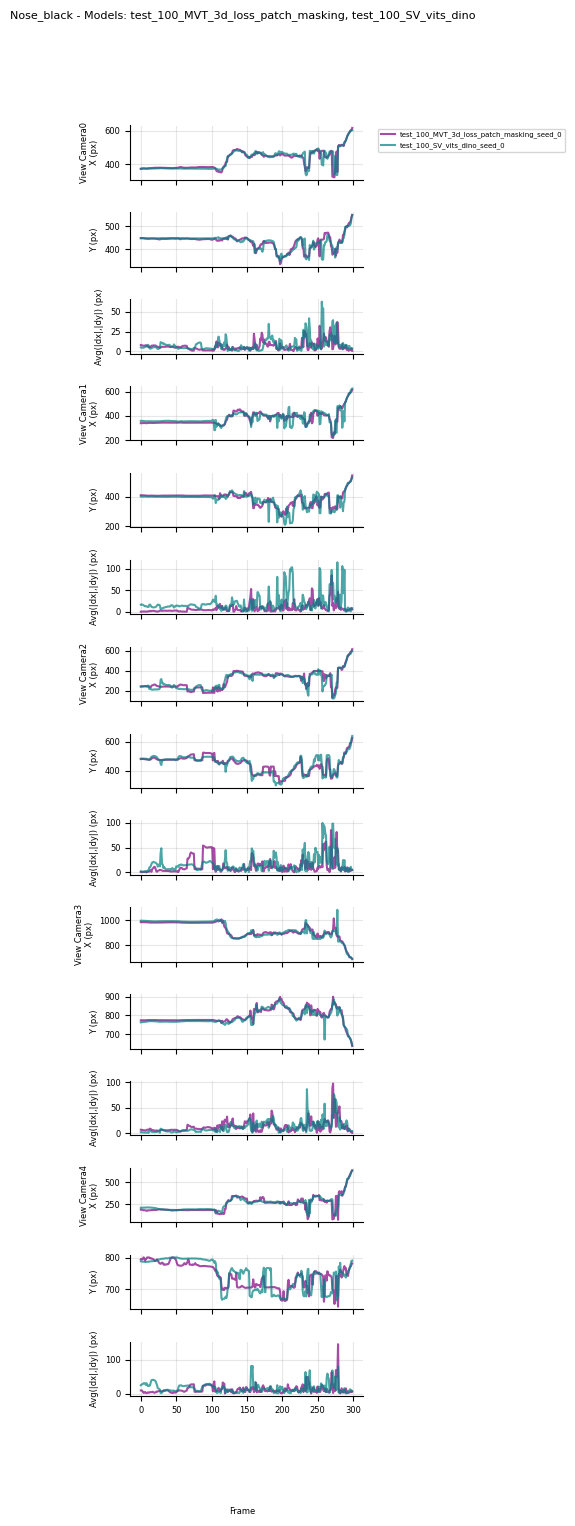


Plotting keypoint: Nose_white


/tmp/ipykernel_138738/1159185269.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


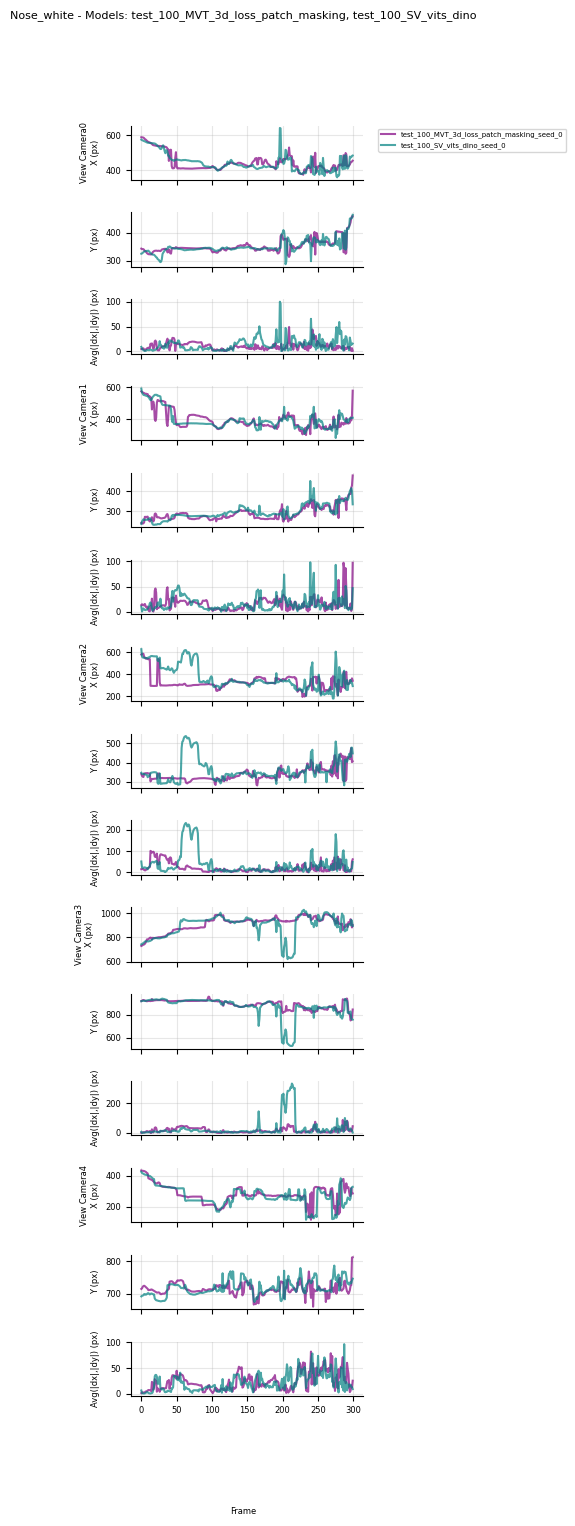


Plotting keypoint: TTI_black


/tmp/ipykernel_138738/1159185269.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


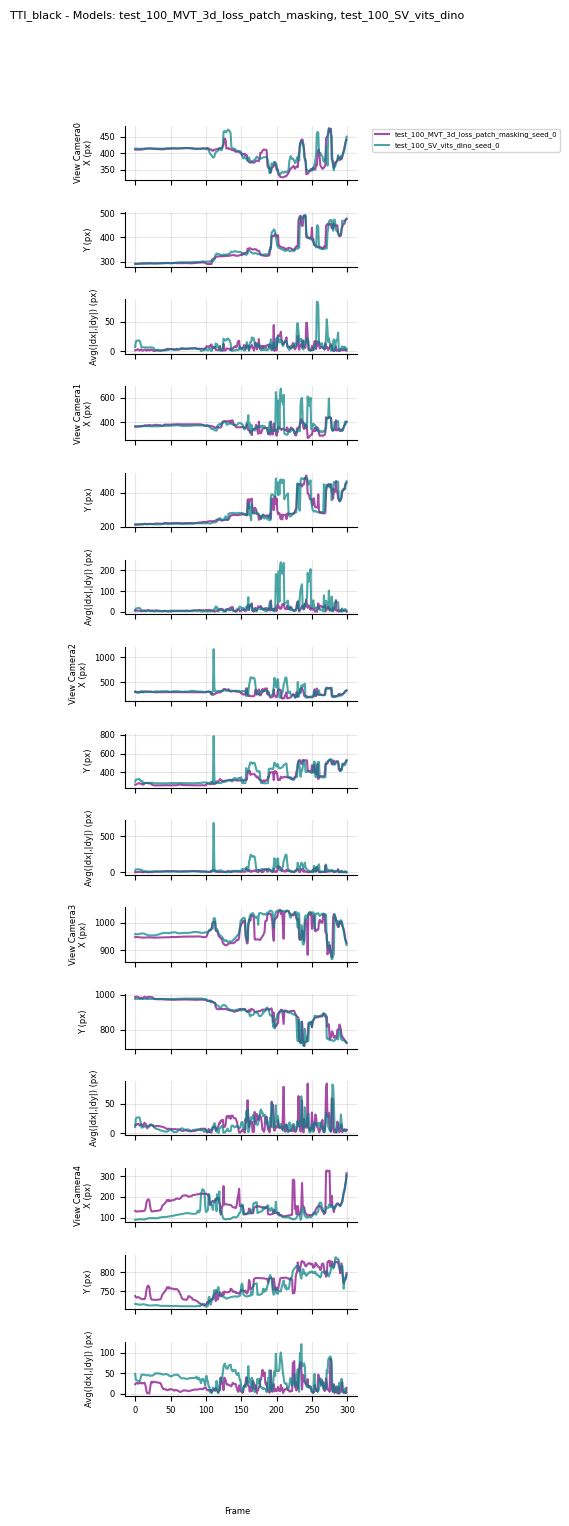


Plotting keypoint: TTI_white


/tmp/ipykernel_138738/1159185269.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


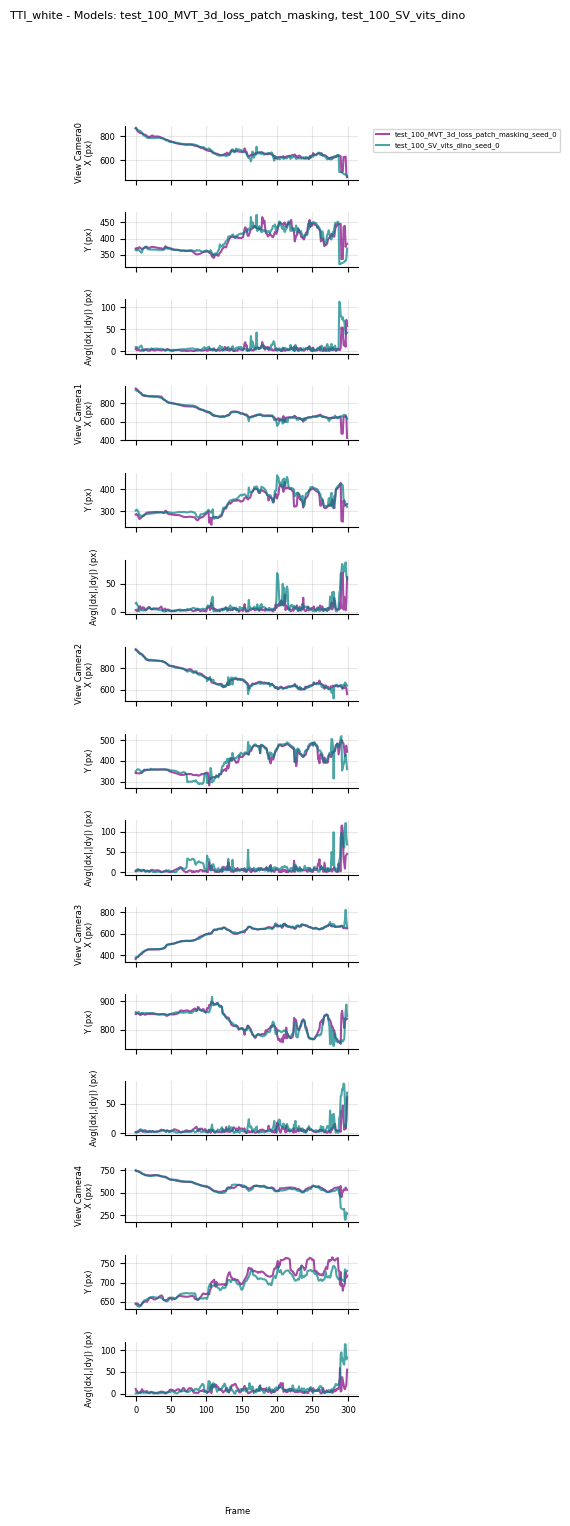

In [18]:
# model_keys = ['test_200_MVT_3d_loss_patch_masking', 'test_200_SV_vits_dino']
model_keys = ['test_100_MVT_3d_loss_patch_masking', 'test_100_SV_vits_dino']
if dataset_name == 'mirror-mouse-separate':
    keypoints_to_plot = ['paw1LH', 'paw2LF']
    model_keys = ['test_200_MVT_patch_masking', 'test_200_SV_vits_dino']
elif dataset_name == 'chickadee-crop':
    keypoints_to_plot = ['topBeak','botBeak','topHead']
elif dataset_name == 'fly-anipose':
    keypoints_to_plot = ['L1E', 'L2E']
elif dataset_name == 'ibl-mouse':
    keypoints_to_plot = ['pawL', 'pawR']
    model_keys = ['test_200_multiview_resnet50_new_labels', 'test_200_MVT_3d_aug_patch_masking_new_labels']
elif dataset_name == 'two-mouse':
    keypoints_to_plot = ['Nose_black', 'Nose_white', 'TTI_black', 'TTI_white']

# I want to be able to save the plots in the following folder 
output_dir = f'/teamspace/studios/this_studio/outputs/{dataset_name}/plots/traces_reconstruct'

fig =create_tracking_plots_simplified(
    data=data,
    model_keys=model_keys,
    colors=custom_colors,
    keypoints_to_plot=keypoints_to_plot,
    keypoint_names=keypoint_names,
    views=views,
    seeds_to_plot=['0'], # mirror mouse is seed 0, fly seed 0 , chickadee seed 0
    plot_x=True,
    plot_y=True,
    plot_reprojection_error=False,
    plot_reprojection_error_x=False,
    plot_reprojection_error_y=False,
    plot_avg_reprojection_error=True,
    plot_global_avg_error=False,
    compare_models=True,
    show_plot=True,
    file_type='pdf',
    save_path=output_dir,
    filename_suffix=f'{dataset_name}_traces'
)


